# 1. Connect to Neo4j and Export Graph Data

In [1]:
from neo4j import GraphDatabase
from sentence_transformers import SentenceTransformer, util
import torch, itertools, tqdm

device = torch.device("cpu")  

# --------------------------------------------------------------
# 1.  Neo4j connection
# --------------------------------------------------------------
NEO4J_URI      = "bolt://localhost:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "root1234"
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# --------------------------------------------------------------
# 2.  Pull *rich* text for each Person  ⇢  persons_text[p_idx]  (str)
#     – name
#     – every Experience.role + Experience.description
#     – every Skill.name
# --------------------------------------------------------------
cypher_person = """
MATCH (p:Person)
OPTIONAL MATCH (p)-[:HAS_EXPERIENCE]->(e:Experience)
OPTIONAL MATCH (p)-[:HAS_SKILL]->(s:Skill)
WITH id(p)      AS pid,
     p.name     AS pname,
     collect(e.role + ' ; ' + coalesce(e.description,'')) AS exps,
     collect(s.name)                                       AS skills
RETURN pid,
       pname +
       ' ; ' + apoc.text.join(exps  , ' ; ') +
       ' ; ' + apoc.text.join(skills, ' ; ')               AS blob
"""
# If APOC is not installed, just collect in Python – see comment below.

# ----------------------------------------------------------------
# 3.  Pull text for each Attack node  ⇢  attacks_text[a_idx]  (str)
# ----------------------------------------------------------------
cypher_attack = """
MATCH (a:Attack)
RETURN id(a) AS aid,
       coalesce(a.name,'') + ' ; ' + coalesce(a.description,'') AS blob
"""

# ----------------------------------------------------------------
# 4.  Pull (Person)‑[:CAN_MITIGATES]‑>(Attack) edges
# ----------------------------------------------------------------
cypher_edges = """
MATCH (p:Person)-[:CAN_MITIGATE]->(a:Attack)
RETURN id(p) AS pid, id(a) AS aid
"""

# ----------------------------------------------------------------
# 5.  Query Neo4j and build dictionaries / lists
# ----------------------------------------------------------------
person_id_map, attack_id_map = {}, {}
persons_text, attacks_text   = [], []
with driver.session() as sess:
    # Persons
    for rec in sess.run(cypher_person):
        pid, blob = rec["pid"], (rec["blob"] or "").strip()
        if not blob:                                   # fallback to just the name
            blob = rec["pname"]
        person_id_map[pid] = len(person_id_map)
        persons_text.append(blob)

    # Attacks
    for rec in sess.run(cypher_attack):
        aid, blob = rec["aid"], (rec["blob"] or "").strip()
        attack_id_map[aid] = len(attack_id_map)
        attacks_text.append(blob)

    # Edges
    person_attack_edges = []
    for rec in sess.run(cypher_edges):
        p_idx = person_id_map.get(rec["pid"])
        a_idx = attack_id_map.get(rec["aid"])
        if p_idx is not None and a_idx is not None:
            person_attack_edges.append((p_idx, a_idx))

print(f"Persons: {len(persons_text)},  Attacks: {len(attacks_text)},  Edges: {len(person_attack_edges)}")




/Users/chengxiyao/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Persons: 958,  Attacks: 1574,  Edges: 4914


In [2]:
#persons_text

# 2. Text Feature Extraction with BERT

In [3]:
# ----------------------------------------------------------------
# 6.  Encode with BERT (Sentence‑Transformers)
# ----------------------------------------------------------------
import math
bert = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")   # use CPU or "cuda" if available
BATCH = 128

def batch_embed(texts):
    embeds = []
    for batch in tqdm.tqdm(list(itertools.zip_longest(*[iter(texts)]*BATCH, fillvalue=None)),
                           total=math.ceil(len(texts)/BATCH),
                           desc="Embedding"):
        chunk = [t for t in batch if t is not None]
        if chunk:
            embeds.extend(bert.encode(chunk, show_progress_bar=False, convert_to_tensor=True))
    return torch.stack(embeds)

person_features = batch_embed(persons_text)   # tensor [N_person, 384]
attack_features = batch_embed(attacks_text)   # tensor [N_attack, 384]



Embedding: 100%|██████████████████████████████████| 7/7 [00:12<00:00,  1.82s/it]


# Construct the Heterogeneous Graph for GNN

In [4]:
# ----------------------------------------------------------------
# 7.  Ready to build PyG HeteroData
# ----------------------------------------------------------------
from torch_geometric.data import HeteroData

data = HeteroData()
# Set node type features
data["Person"].x = person_features        # Person node feature matrix
data["Attack"].x = attack_features        # Attack node feature matrix
data["Person"].num_nodes = person_features.size(0)
data["Attack"].num_nodes = attack_features.size(0)
# Build edge index tensors
edge_index_P2A = torch.tensor(list(zip(*person_attack_edges)), dtype=torch.long)
# person_attack_edges is a list of (p_idx, a_idx); we transpose to shape [2, num_edges]
data[("Person", "mitigates", "Attack")].edge_index = edge_index_P2A
# Add reverse edges for Attack->Person (for undirected message passing)
edge_index_A2P = torch.stack([edge_index_P2A[1], edge_index_P2A[0]], dim=0)
data[("Attack", "rev_mitigates", "Person")].edge_index = edge_index_A2P

print(data)
# HeteroData object printing the meta information, e.g.:
# HeteroData(
#   Person={ x: [N_person, F] },
#   Attack={ x: [N_attack, F] },
#   (Person, 'mitigates', 'Attack')={ edge_index: [2, E] },
#   (Attack, 'rev_mitigates', 'Person')={ edge_index: [2, E] }
# )

HeteroData(
  Person={
    x=[702, 384],
    num_nodes=702,
  },
  Attack={
    x=[794, 384],
    num_nodes=794,
  },
  (Person, mitigates, Attack)={ edge_index=[2, 12127] },
  (Attack, rev_mitigates, Person)={ edge_index=[2, 12127] }
)


In [5]:
import random
# Prepare positive edges list

random.seed(42)               
all_edges = person_attack_edges
random.shuffle(all_edges)
split_pos = int(0.8 * len(all_edges))
train_pos_edges = all_edges[:split_pos]
test_pos_edges  = all_edges[split_pos:]

# Generate negative samples for training and testing
all_person_idx = list(range(len(persons_text)))
all_attack_idx = list(range(len(attacks_text)))
existing_pairs = set((p,a) for p,a in all_edges)

def sample_negative_edges(num_samples):
    neg_edges = []
    while len(neg_edges) < num_samples:
        p = random.choice(all_person_idx)
        a = random.choice(all_attack_idx)
        if (p, a) not in existing_pairs:
            neg_edges.append((p, a))
            existing_pairs.add((p, a))  # avoid duplicates
    return neg_edges

train_neg_edges = sample_negative_edges(len(train_pos_edges))
test_neg_edges  = sample_negative_edges(len(test_pos_edges))

print(f"Training positive edges: {len(train_pos_edges)}, negative edges: {len(train_neg_edges)}")
print(f"Testing positive edges: {len(test_pos_edges)}, negative edges: {len(test_neg_edges)}")

Training positive edges: 9701, negative edges: 9701
Testing positive edges: 2426, negative edges: 2426


# 4.2 Relational GCN (R-GCN)

In [6]:
from torch_geometric.nn import RGCNConv
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score   

# Prepare data for R-GCN: combine Person and Attack into one graph
N_person = person_features.size(0)
N_attack = attack_features.size(0)
# Concatenate person and attack features (ensure they have same feature size)
all_features = torch.cat([person_features, attack_features], dim=0)  # shape [N_total, F]
# Create edge index and type arrays for R-GCN (with directed edges)
# Using relation type 0 for Person->Attack, 1 for Attack->Person
src_list = edge_index_P2A[0].tolist()
dst_list = edge_index_P2A[1].tolist()
# Person->Attack edges (relation 0)
edge_index_list = [src_list, [d + N_person for d in dst_list]]  # offset attack indices in combined indexing
edge_type_list = [0] * len(src_list)
# Attack->Person edges (relation 1)
src_rev = edge_index_A2P[0].tolist()
dst_rev = edge_index_A2P[1].tolist()
edge_index_list[0].extend([s + N_person for s in src_rev])  # offset attack indices in src
edge_index_list[1].extend(dst_rev) 
edge_type_list.extend([1] * len(src_rev))
# Final edge index tensor and edge type tensor
edge_index_homo = torch.tensor(edge_index_list, dtype=torch.long)       # shape [2, E_total]
edge_type = torch.tensor(edge_type_list, dtype=torch.long)              # shape [E_total]

# Define R-GCN model
import torch.nn as nn

class RGCNLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_relations):
        super().__init__()
        self.conv1 = RGCNConv(in_channels, hidden_channels, num_relations)
        self.conv2 = RGCNConv(hidden_channels, out_channels, num_relations)
    def forward(self, x, edge_index, edge_type):
        # Two-layer R-GCN
        h = F.relu(self.conv1(x, edge_index, edge_type))
        h = self.conv2(h, edge_index, edge_type)
        return h

# Instantiate model (assuming input feature dim = F, hidden dim = 64, out dim = 32)
model = RGCNLinkPredictor(in_channels=all_features.size(1), hidden_channels=64, out_channels=32, num_relations=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop for R-GCN link prediction
for epoch in range(1, 5):
    model.train()
    total_loss = 0
    # We'll do full-batch training (for simplicity, although we could sample edges in batches)
    # Prepare training labels and predictions
    # Forward pass to get node embeddings
    emb = model(all_features, edge_index_homo, edge_type)  # shape [N_total, out_channels]
    # Compute scores for each training edge (positive and negative)
    pos_scores = []
    neg_scores = []
    for (p, a) in train_pos_edges:
        # Map p (Person index) and a (Attack index) to combined index in 'emb'
        node_p = p  # person index (0-based)
        node_a = N_person + a  # attack index offset by N_person
        score = (emb[node_p] * emb[node_a]).sum()  # dot-product score
        pos_scores.append(score)
    for (p, a) in train_neg_edges:
        node_p = p
        node_a = N_person + a
        score = (emb[node_p] * emb[node_a]).sum()
        neg_scores.append(score)
    pos_scores = torch.stack(pos_scores)  # tensor of shape [len(train_pos_edges)]
    neg_scores = torch.stack(neg_scores)
    # Labels
    labels_pos = torch.ones_like(pos_scores)
    labels_neg = torch.zeros_like(neg_scores)
    # Binary cross-entropy loss
    loss_pos = F.binary_cross_entropy_with_logits(pos_scores, labels_pos)
    loss_neg = F.binary_cross_entropy_with_logits(neg_scores, labels_neg)
    loss = loss_pos + loss_neg
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss = loss.item()
    print(f"Epoch {epoch}, training loss: {total_loss:.4f}")

# Evaluation for R-GCN
model.eval()
emb = model(all_features, edge_index_homo, edge_type)
# Compute scores for test edges
pos_scores = []
neg_scores = []
for (p, a) in test_pos_edges:
    score = (emb[p] * emb[N_person + a]).sum().item()
    pos_scores.append(score)
for (p, a) in test_neg_edges:
    score = (emb[p] * emb[N_person + a]).sum().item()
    neg_scores.append(score)
# AUC
all_scores = pos_scores + neg_scores
all_labels = [1]*len(pos_scores) + [0]*len(neg_scores)
auc = roc_auc_score(all_labels, all_scores)
print(f"R-GCN Link Prediction AUC: {auc:.4f}")
# Hits@K
K = 10
hits = 0
for p, a in test_pos_edges:
    # sample 100 random negative persons for this attack
    negative_persons = random.sample(all_person_idx, 100)
    negative_persons = [x for x in negative_persons if (x, a) not in existing_pairs]
    candidates = negative_persons + [p]
    scores = [(emb[c] * emb[N_person + a]).sum().item() for c in candidates]
    # get rank of true person
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:K]
    if len(candidates)-1 in top_idx:
        hits += 1
hits_rate = hits / len(test_pos_edges)
print(f"R-GCN Hits@{K}: {hits_rate:.4f}")

Epoch 1, training loss: 1.3833
Epoch 2, training loss: 1.2640
Epoch 3, training loss: 1.4488
Epoch 4, training loss: 0.9487
R-GCN Link Prediction AUC: 0.9817
R-GCN Hits@10: 0.8755


In [7]:
# ------------------------------------------------------------------
# Evaluation for R‑GCN
# ------------------------------------------------------------------
from sklearn.metrics import roc_auc_score                              # already added above
import numpy as np                                                     # NEW

model.eval()
emb = model(all_features, edge_index_homo, edge_type)

# ----- (1)  AUC on the link‑level -------------------------------------------------
pos_scores = [(emb[p] * emb[N_person + a]).sum().item()
              for p, a in test_pos_edges]
neg_scores = [(emb[p] * emb[N_person + a]).sum().item()
              for p, a in test_neg_edges]
auc  = roc_auc_score([1]*len(pos_scores)+[0]*len(neg_scores),
                     pos_scores+neg_scores)
print(f"AUC = {auc:.4f}")

# ----- (2)  Top‑K metrics ---------------------------------------------------------
for k in [1,3,5,7]:
    K = k
    hits = 0
    precisions = []         # NEW
    for p, a in test_pos_edges:
        # sample 100 random negative persons for this attack
        negatives = random.sample(all_person_idx, 100)
        negatives = [x for x in negatives if (x, a) not in existing_pairs]
        candidates = negatives + [p]                   # last index is the true person
        scores = [(emb[c] * emb[N_person + a]).sum().item()
                  for c in candidates]
        # indices of the K highest‑scoring candidates
        top_k_idx = np.argsort(scores)[-K:][::-1]      # descending order
        if len(candidates) - 1 in top_k_idx:           # hit?
            hits += 1
            precisions.append(1.0)                 # pos is 1 of the K results
        else:
            precisions.append(0.0)

    num_queries   = len(test_pos_edges)
    recall_at_k   = hits / num_queries
    precision_at_k= sum(precisions) / num_queries
    accuracy_at_k = precision_at_k     
    f1_at_k = 2 * (recall_at_k * precision_at_k)/(recall_at_k + precision_at_k)# identical in this setup

    print(f"Recall@{K}    = {recall_at_k:.3f}")
    print(f"Precision@{K} = {precision_at_k:.3f}")
    print(f"Accuracy@{K}  = {accuracy_at_k:.3f}")
    print(f"F1@{K}  = {f1_at_k:.3f}")
    

AUC = 0.9817
Recall@1    = 0.670
Precision@1 = 0.670
Accuracy@1  = 0.670
F1@1  = 0.670
Recall@3    = 0.794
Precision@3 = 0.794
Accuracy@3  = 0.794
F1@3  = 0.794
Recall@5    = 0.822
Precision@5 = 0.822
Accuracy@5  = 0.822
F1@5  = 0.822
Recall@7    = 0.845
Precision@7 = 0.845
Accuracy@7  = 0.845
F1@7  = 0.845


In [8]:
# ------------------------------------------------------------------
# Top‑K evaluation for arbitrary #positives per attack
# ------------------------------------------------------------------
K = 3
prec_sum, rec_sum, acc_hits = 0.0, 0.0, 0
num_queries = 0

# 1️⃣  Build a dict  attack_id  ->  list of true person indices in *test* set
from collections import defaultdict
attack2positives = defaultdict(list)
for p,a in test_pos_edges:          # test_pos_edges already split earlier
    attack2positives[a].append(p)

# 2️⃣  Evaluate each attack separately
for a, true_ps in attack2positives.items():
    num_queries += 1
    # candidate pool = all true experts + 100 random negatives
    negatives = random.sample(all_person_idx, 100)
    negatives = [x for x in negatives if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + negatives))          # unique ids

    # scores for Person_i  vs.  Attack_a
    attack_vec = emb[N_person + a]
    scores = [(pid, (emb[pid] * attack_vec).sum().item()) for pid in candidates]
    # rank by score descending
    top_k = sorted(scores, key=lambda t: t[1], reverse=True)[:K]
    top_ids = {pid for pid, _ in top_k}

    # per‑query metrics
    true_in_top = len(top_ids.intersection(true_ps))
    prec_sum += true_in_top / K
    rec_sum  += true_in_top / len(true_ps)
    if true_in_top > 0:             # accuracy hit
        acc_hits += 1

# 3️⃣  Aggregate
precision_at_k = prec_sum / num_queries
recall_at_k    = rec_sum  / num_queries
accuracy_at_k  = acc_hits / num_queries

print(f"Precision@{K} = {precision_at_k:.3f}")
print(f"Recall@{K}    = {recall_at_k:.3f}")
print(f"Accuracy@{K}  = {accuracy_at_k:.3f}")

Precision@3 = 0.263
Recall@3    = 0.059
Accuracy@3  = 0.387


In [9]:
# ------------------------------------------------------------------
# Top‑K evaluation with global precision definition
# ------------------------------------------------------------------
K = 3
total_true_returned = 0      # how many correct links appear in top‑K overall
accuracy_hits       = 0      # queries where at least one correct link is in top‑K
num_queries         = 0

attack2positives = {}
for p, a in test_pos_edges:                      # build ground‑truth map
    attack2positives.setdefault(a, []).append(p)

for a, true_ps in attack2positives.items():
    num_queries += 1
    # candidate pool  = true experts + 100 random negatives
    neg = random.sample(all_person_idx, 100)
    neg = [x for x in neg if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + neg))

    # score every candidate (Person, Attack_a)
    attack_vec = emb[N_person + a]
    scores = [(pid, (emb[pid] * attack_vec).sum().item()) for pid in candidates]
    # pick top‑K by score
    top_k_ids = {pid for pid, _ in sorted(scores, key=lambda t: t[1], reverse=True)[:K]}

    # update counters
    hits_here = len(top_k_ids.intersection(true_ps))
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / sum(len(v) for v in attack2positives.values())
accuracy_at_k  = accuracy_hits       / num_queries

print(f"Precision@{K} = {precision_at_k:.3f}")
print(f"Recall@{K}    = {recall_at_k:.3f}")
print(f"Accuracy@{K}  = {accuracy_at_k:.3f}")

Precision@3 = 0.255
Recall@3    = 0.038
Accuracy@3  = 0.412


In [10]:
# ------------------------------------------------------------------
# ----- (2)  Top‑K metrics (precision, recall, accuracy) ----------
# ------------------------------------------------------------------
K = 3
total_true_returned = 0       # counts *all* true links that appear in top‑K
accuracy_hits       = 0       # queries where at least one true link is in top‑K
num_queries         = 0

# build   attack_id  ->  [true_person_ids]   map from your test positives
from collections import defaultdict
attack2positives = defaultdict(list)
for p, a in test_pos_edges:
    attack2positives[a].append(p)

for a, true_ps in attack2positives.items():
    num_queries += 1

    # ----- candidate pool = all true experts + 100 random negatives -----------
    negatives = random.sample(all_person_idx, 100)
    negatives = [x for x in negatives if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + negatives))          # unique person ids

    # ----- score every candidate ---------------------------------------------
    attack_vec = emb[N_person + a]
    scores = [(pid, (emb[pid] * attack_vec).sum().item()) for pid in candidates]

    # top‑K by score (descending)
    top_k_ids = {pid for pid, _ in sorted(scores, key=lambda t: t[1],
                                          reverse=True)[:K]}

    # ----- bookkeeping --------------------------------------------------------
    hits_here = len(top_k_ids.intersection(true_ps))     # how many true in top‑K
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

# ----- final metrics ----------------------------------------------------------
precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / sum(len(v) for v in attack2positives.values())
accuracy_at_k  = accuracy_hits       / num_queries

print(f"Precision@{K} = {precision_at_k:.3f}")
print(f"Recall@{K}    = {recall_at_k:.3f}")
print(f"Accuracy@{K}  = {accuracy_at_k:.3f}")

Precision@3 = 0.277
Recall@3    = 0.041
Accuracy@3  = 0.437


R-GCN AUC: 0.9817


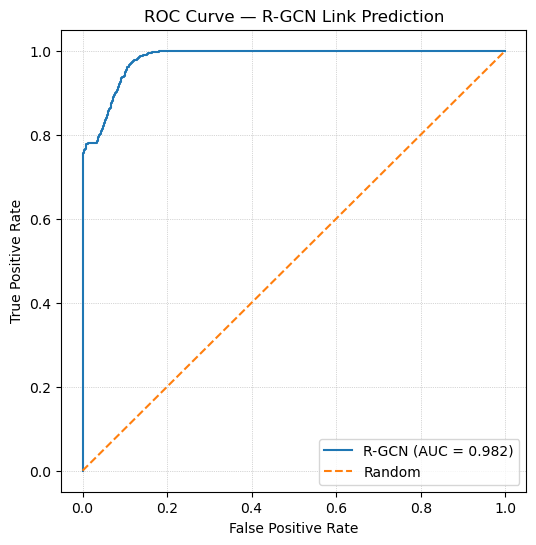

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Prepare true labels and score list
y_true  = [1] * len(pos_scores) + [0] * len(neg_scores)
y_score = pos_scores + neg_scores

# 2. Compute ROC curve and AUC
fpr, tpr, _   = roc_curve(y_true, y_score)
auc_value     = roc_auc_score(y_true, y_score)
print(f"R-GCN AUC: {auc_value:.4f}")

# 3. Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"R-GCN (AUC = {auc_value:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — R-GCN Link Prediction")
plt.legend(loc="lower right")
plt.grid(linestyle=":", linewidth=0.5)
plt.show()

# 4.3 GraphSAGE (Heterogeneous variant)

In [12]:
from torch_geometric.nn import SAGEConv, HeteroConv

class HeteroGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, metadata):
        super().__init__()
        # First layer: define a SAGEConv for each relation type
        self.conv1 = HeteroConv({
            ("Person", "mitigates", "Attack"): SAGEConv((-1, -1), hidden_channels),
            ("Attack", "rev_mitigates", "Person"): SAGEConv((-1, -1), hidden_channels),
        }, aggr='sum')
        # Second layer
        self.conv2 = HeteroConv({
            ("Person", "mitigates", "Attack"): SAGEConv((-1, -1), out_channels),
            ("Attack", "rev_mitigates", "Person"): SAGEConv((-1, -1), out_channels),
        }, aggr='sum')
    def forward(self, x_dict, edge_index_dict):
        # x_dict: {"Person": person_feats, "Attack": attack_feats}
        # edge_index_dict contains edge indices for ("Person","mitigates","Attack") and its reverse.
        out_dict1 = self.conv1(x_dict, edge_index_dict)  # hetero conv layer 1
        # Apply non-linearity
        out_dict1 = {k: F.relu(h) for k, h in out_dict1.items()}
        out_dict2 = self.conv2(out_dict1, edge_index_dict)  # layer 2
        return out_dict2  # returns a dict of node type -> embeddings

# Instantiate model
metadata = (list(data.node_types), list(data.edge_types))
model = HeteroGraphSAGE(in_channels=person_features.size(1), hidden_channels=32, out_channels=32, metadata=metadata)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop (full-batch for simplicity)
for epoch in range(1, 6):
    model.train()
    out = model({"Person": data["Person"].x, "Attack": data["Attack"].x}, data.edge_index_dict)
    # out is a dict: out["Person"] (shape [N_person, out_dim]), out["Attack"] ([N_attack, out_dim])
    person_latent = out["Person"]
    attack_latent = out["Attack"]
    # Compute loss on training edges
    pos_scores = []
    neg_scores = []
    for (p, a) in train_pos_edges:
        score = (person_latent[p] * attack_latent[a]).sum()
        pos_scores.append(score)
    for (p, a) in train_neg_edges:
        score = (person_latent[p] * attack_latent[a]).sum()
        neg_scores.append(score)
    pos_scores = torch.stack(pos_scores)
    neg_scores = torch.stack(neg_scores)
    loss = F.binary_cross_entropy_with_logits(pos_scores, torch.ones_like(pos_scores)) + \
           F.binary_cross_entropy_with_logits(neg_scores, torch.zeros_like(neg_scores))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
out = model({"Person": data["Person"].x, "Attack": data["Attack"].x}, data.edge_index_dict)
person_latent = out["Person"]; attack_latent = out["Attack"]
pos_scores = [(person_latent[p] * attack_latent[a]).sum().item() for p, a in test_pos_edges]
neg_scores = [(person_latent[p] * attack_latent[a]).sum().item() for p, a in test_neg_edges]
auc = roc_auc_score([1]*len(pos_scores)+[0]*len(neg_scores), pos_scores+neg_scores)
print(f"Hetero-GraphSAGE Link Prediction AUC: {auc:.4f}")
# Hits@K
K = 10
hits = 0
for p, a in test_pos_edges:
    negative_persons = random.sample(all_person_idx, 100)
    negative_persons = [x for x in negative_persons if (x, a) not in existing_pairs]
    candidates = negative_persons + [p]
    scores = [(person_latent[c] * attack_latent[a]).sum().item() for c in candidates]
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:K]
    if len(candidates)-1 in top_idx:
        hits += 1
hits_rate = hits / len(test_pos_edges)
print(f"Hetero-GraphSAGE Hits@{K}: {hits_rate:.4f}")

Epoch 1, Loss: 1.3881
Epoch 2, Loss: 1.2508
Epoch 3, Loss: 0.9761
Epoch 4, Loss: 0.7462
Epoch 5, Loss: 0.4708
Hetero-GraphSAGE Link Prediction AUC: 0.9836
Hetero-GraphSAGE Hits@10: 0.8636


In [13]:
from torch_geometric.nn import SAGEConv, HeteroConv

class HeteroGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, metadata):
        super().__init__()
        # First layer: define a SAGEConv for each relation type
        self.conv1 = HeteroConv({
            ("Person", "mitigates", "Attack"): SAGEConv((-1, -1), hidden_channels),
            ("Attack", "rev_mitigates", "Person"): SAGEConv((-1, -1), hidden_channels),
        }, aggr='sum')
        # Second layer
        self.conv2 = HeteroConv({
            ("Person", "mitigates", "Attack"): SAGEConv((-1, -1), out_channels),
            ("Attack", "rev_mitigates", "Person"): SAGEConv((-1, -1), out_channels),
        }, aggr='sum')
    def forward(self, x_dict, edge_index_dict):
        # x_dict: {"Person": person_feats, "Attack": attack_feats}
        # edge_index_dict contains edge indices for ("Person","mitigates","Attack") and its reverse.
        out_dict1 = self.conv1(x_dict, edge_index_dict)  # hetero conv layer 1
        # Apply non-linearity
        out_dict1 = {k: F.relu(h) for k, h in out_dict1.items()}
        out_dict2 = self.conv2(out_dict1, edge_index_dict)  # layer 2
        return out_dict2  # returns a dict of node type -> embeddings

# Instantiate model
metadata = (list(data.node_types), list(data.edge_types))
model = HeteroGraphSAGE(in_channels=person_features.size(1), hidden_channels=32, out_channels=32, metadata=metadata)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop (full-batch for simplicity)
for epoch in range(1, 6):
    model.train()
    out = model({"Person": data["Person"].x, "Attack": data["Attack"].x}, data.edge_index_dict)
    # out is a dict: out["Person"] (shape [N_person, out_dim]), out["Attack"] ([N_attack, out_dim])
    person_latent = out["Person"]
    attack_latent = out["Attack"]
    # Compute loss on training edges
    pos_scores = []
    neg_scores = []
    for (p, a) in train_pos_edges:
        score = (person_latent[p] * attack_latent[a]).sum()
        pos_scores.append(score)
    for (p, a) in train_neg_edges:
        score = (person_latent[p] * attack_latent[a]).sum()
        neg_scores.append(score)
    pos_scores = torch.stack(pos_scores)
    neg_scores = torch.stack(neg_scores)
    loss = F.binary_cross_entropy_with_logits(pos_scores, torch.ones_like(pos_scores)) + \
           F.binary_cross_entropy_with_logits(neg_scores, torch.zeros_like(neg_scores))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
out = model({"Person": data["Person"].x, "Attack": data["Attack"].x}, data.edge_index_dict)
person_latent = out["Person"]; attack_latent = out["Attack"]
pos_scores = [(person_latent[p] * attack_latent[a]).sum().item() for p, a in test_pos_edges]
neg_scores = [(person_latent[p] * attack_latent[a]).sum().item() for p, a in test_neg_edges]
auc = roc_auc_score([1]*len(pos_scores)+[0]*len(neg_scores), pos_scores+neg_scores)
print(f"Hetero-GraphSAGE Link Prediction AUC: {auc:.4f}")
# Hits@K
K = 10
hits = 0
for p, a in test_pos_edges:
    negative_persons = random.sample(all_person_idx, 100)
    negative_persons = [x for x in negative_persons if (x, a) not in existing_pairs]
    candidates = negative_persons + [p]
    scores = [(person_latent[c] * attack_latent[a]).sum().item() for c in candidates]
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:K]
    if len(candidates)-1 in top_idx:
        hits += 1
hits_rate = hits / len(test_pos_edges)
print(f"Hetero-GraphSAGE Hits@{K}: {hits_rate:.4f}")

Epoch 1, Loss: 1.3865
Epoch 2, Loss: 1.2693
Epoch 3, Loss: 0.9669
Epoch 4, Loss: 0.6823
Epoch 5, Loss: 0.4714
Hetero-GraphSAGE Link Prediction AUC: 0.9794
Hetero-GraphSAGE Hits@10: 0.8858


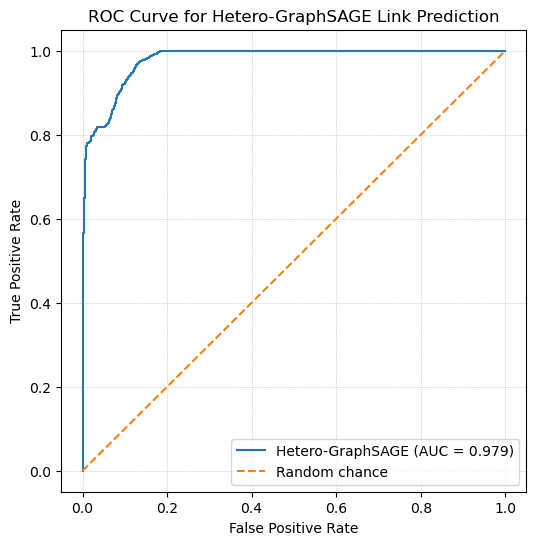

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Prepare labels and scores
y_true  = [1] * len(pos_scores) + [0] * len(neg_scores)
y_score = pos_scores + neg_scores

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_val     = roc_auc_score(y_true, y_score)

# Plot it
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Hetero-GraphSAGE (AUC = {auc_val:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Hetero-GraphSAGE Link Prediction")
plt.legend(loc="lower right")
plt.grid(linestyle=":", linewidth=0.5)
plt.show()

In [14]:
# ------------------------------------------------------------------
# Precision / Recall / Accuracy @ K   (handles ≥1 true experts/attack)
# ------------------------------------------------------------------
K = 5
total_true_returned = 0         # all correct links surfaced in top‑K
accuracy_hits       = 0         # attacks where ≥1 correct expert in top‑K
num_queries         = 0

# build   attack_id  ->  list[true_person_idx]   from test positives
from collections import defaultdict
attack2positives = defaultdict(list)
for p, a in test_pos_edges:
    attack2positives[a].append(p)

for a, true_ps in attack2positives.items():
    num_queries += 1

    # candidate pool = all true experts + 100 random negatives
    negatives = random.sample(all_person_idx, 100)
    negatives = [x for x in negatives if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + negatives))

    # score every candidate Person vs. this Attack
    attack_vec = attack_latent[a]
    scores = [(pid, (person_latent[pid] * attack_vec).sum().item())
              for pid in candidates]

    # take top‑K
    top_k_ids = {pid for pid, _ in sorted(scores, key=lambda t: t[1],
                                          reverse=True)[:K]}

    # bookkeeping
    hits_here = len(top_k_ids.intersection(true_ps))   # how many of the true links are returned
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

# global metrics
precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / sum(min(len(v),K) for v in attack2positives.values())
accuracy_at_k  = accuracy_hits       / num_queries

print(f"Precision@{K} = {precision_at_k:.3f}")
print(f"Recall@{K}    = {recall_at_k:.3f}")
print(f"Accuracy@{K}  = {accuracy_at_k:.3f}")

Precision@5 = 0.291
Recall@5    = 0.470
Accuracy@5  = 0.496


In [15]:
# ----- (2)  Top‑K metrics (global precision / recall / accuracy) ----
K = 10
total_true_returned = 0          # all true links that appear in top‑K
accuracy_hits       = 0          # queries where ≥1 true link is in top‑K
num_queries         = 0

from collections import defaultdict
attack2positives = defaultdict(list)
for p, a in test_pos_edges:                # build ground‑truth map
    attack2positives[a].append(p)

for a, true_ps in attack2positives.items():
    num_queries += 1

    # candidate pool: true experts + 100 random negatives
    neg = random.sample(all_person_idx, 100)
    neg = [x for x in neg if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + neg))

    # score every candidate Person vs. this Attack
    attack_vec = emb[N_person + a]
    scores = [(pid, (emb[pid] * attack_vec).sum().item()) for pid in candidates]

    # top‑K by score
    top_k_ids = {pid for pid, _ in sorted(scores,
                                          key=lambda t: t[1],
                                          reverse=True)[:K]}

    hits_here = len(top_k_ids.intersection(true_ps))
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / (len(attack2positives.values()) *K)
accuracy_at_k  = accuracy_hits       / num_queries

print(f"Recall@{K}    = {recall_at_k:.3f}")
print(f"Precision@{K} = {precision_at_k:.3f}")
print(f"Accuracy@{K}  = {accuracy_at_k:.3f}")

Recall@10    = 0.266
Precision@10 = 0.266
Accuracy@10  = 0.613


In [16]:
model.eval()

HeteroGraphSAGE(
  (conv1): HeteroConv(num_relations=2)
  (conv2): HeteroConv(num_relations=2)
)

In [17]:
# ------------------------------------------------------------------
# Precision / Recall / Accuracy @ K  (global definitions)
# ------------------------------------------------------------------
from collections import defaultdict
import numpy as np

K = 3
total_true_returned = 0           # correct links present in top‑K lists
accuracy_hits       = 0           # queries with ≥1 correct link in top‑K
num_queries         = 0

# build  attack_id -> list[true_person_id]  from test positives
attack2positives = defaultdict(list)
for p, a in test_pos_edges:
    attack2positives[a].append(p)

for a, true_ps in attack2positives.items():
    num_queries += 1

    # candidate pool: all true experts + 100 random negatives
    neg = random.sample(all_person_idx, 12)
    neg = [x for x in neg if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + neg))

    # score every candidate Person vs. Attack a
    attack_vec = attack_latent[a]
    scores = [(pid, (person_latent[pid] * attack_vec).sum().item())
              for pid in candidates]

    # select top‑K
    top_k_ids = {pid for pid, _ in sorted(scores,
                                          key=lambda t: t[1],
                                          reverse=True)[:K]}

    hits_here = len(top_k_ids.intersection(true_ps))   # #true links in top‑K
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / sum(min(len(v),K) for v in attack2positives.values())
accuracy_at_k  = accuracy_hits       / num_queries

print(f"Precision@{K}: {precision_at_k:.3f}")
print(f"Recall@{K}:    {recall_at_k:.3f}")
print(f"Accuracy@{K}:  {accuracy_at_k:.3f}")

Precision@3: 0.574
Recall@3:    0.777
Accuracy@3:  0.866


In [18]:
total_true_returned

205

In [19]:
num_queries

119

In [20]:
sum(len(v) for v in attack2positives.values())

2426

# HAN (Heterogeneous Attention Network)

In [22]:
from torch_geometric.nn import HANConv

class HANLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, metadata):
        super().__init__()
        # Use 8 attention heads for the first layer, then 1 head for second layer
        self.han1 = HANConv(in_channels, hidden_channels, heads=8, dropout=0.6, metadata=metadata)
        # After HANConv with heads, the output dimension is hidden_channels (heads are handled internally with averaging)
        self.han2 = HANConv(hidden_channels, out_channels, heads=1, dropout=0.6, metadata=metadata)
    def forward(self, x_dict, edge_index_dict):
        # x_dict: dict of node type -> features
        h_dict = self.han1(x_dict, edge_index_dict)  # first HAN conv
        h_dict = {k: F.relu(h) for k, h in h_dict.items()}
        h_dict = self.han2(h_dict, edge_index_dict)  # second HAN conv
        return h_dict

# Instantiate HAN model
model = HANLinkPredictor(in_channels=person_features.size(1), hidden_channels=32, out_channels=32, metadata=data.metadata())
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Train the HAN model
for epoch in range(1, 6):
    model.train()
    h_dict = model({"Person": data["Person"].x, "Attack": data["Attack"].x}, data.edge_index_dict)
    person_h = h_dict["Person"]; attack_h = h_dict["Attack"]
    # Compute loss on train edges
    pos_logits = torch.stack([(person_h[p] * attack_h[a]).sum() for p, a in train_pos_edges])
    neg_logits = torch.stack([(person_h[p] * attack_h[a]).sum() for p, a in train_neg_edges])
    loss = F.binary_cross_entropy_with_logits(pos_logits, torch.ones_like(pos_logits)) + \
           F.binary_cross_entropy_with_logits(neg_logits, torch.zeros_like(neg_logits))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluate HAN
model.eval()
h_dict = model({"Person": data["Person"].x, "Attack": data["Attack"].x}, data.edge_index_dict)
person_h = h_dict["Person"]; attack_h = h_dict["Attack"]
pos_scores = [(person_h[p] * attack_h[a]).sum().item() for p, a in test_pos_edges]
neg_scores = [(person_h[p] * attack_h[a]).sum().item() for p, a in test_neg_edges]
auc = roc_auc_score([1]*len(pos_scores)+[0]*len(neg_scores), pos_scores+neg_scores)
print(f"HAN Link Prediction AUC: {auc:.4f}")
# Hits@K
K = 10
hits = 0
for p, a in test_pos_edges:
    negative_persons = random.sample(all_person_idx, 100)
    negative_persons = [x for x in negative_persons if (x, a) not in existing_pairs]
    candidates = negative_persons + [p]
    scores = [(person_h[c] * attack_h[a]).sum().item() for c in candidates]
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:K]
    if len(candidates)-1 in top_idx:
        hits += 1
print(f"HAN Hits@{K}: {hits/len(test_pos_edges):.4f}")

Epoch 1, Loss: 1.3645
Epoch 2, Loss: 1.3464
Epoch 3, Loss: 1.3149
Epoch 4, Loss: 1.2816
Epoch 5, Loss: 1.2410
HAN Link Prediction AUC: 0.9479
HAN Hits@10: 0.7791


In [131]:
# ------------------------------------------------------------------
# Precision / Recall / Accuracy @ K  for the HAN embeddings
# ------------------------------------------------------------------
from collections import defaultdict
K = 10

total_true_returned = 0      # ∑ correct links that appear in top‑K
accuracy_hits       = 0      # #queries with ≥1 correct link in top‑K
num_queries         = 0

# Build  attack_id -> [true_person_ids]  from test positives
attack2positives = defaultdict(list)
for p, a in test_pos_edges:
    attack2positives[a].append(p)

for a, true_ps in attack2positives.items():
    num_queries += 1

    # Candidate pool = all true experts + 100 random negatives
    neg = random.sample(all_person_idx, 12)
    neg = [x for x in neg if (x, a) not in existing_pairs]
    candidates = list(set(true_ps + neg))

    # Score every candidate Person vs. Attack a
    attack_vec = attack_h[a]
    scores = [(pid, (person_h[pid] * attack_vec).sum().item()) for pid in candidates]

    # Select top‑K ids
    top_k_ids = {pid for pid, _ in sorted(scores, key=lambda t: t[1], reverse=True)[:K]}

    hits_here = len(top_k_ids.intersection(true_ps))   # how many true links surfaced
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / sum(min(len(v),K) for v in attack2positives.values())
accuracy_at_k  = accuracy_hits       / num_queries

print(f"HAN Precision@{K}: {precision_at_k:.3f}")
print(f"HAN Recall@{K}:    {recall_at_k:.3f}")
print(f"HAN Accuracy@{K}:  {accuracy_at_k:.3f}")

HAN Precision@10: 0.202
HAN Recall@10:    0.434
HAN Accuracy@10:  0.612


HAN Link Prediction AUC: 0.9479


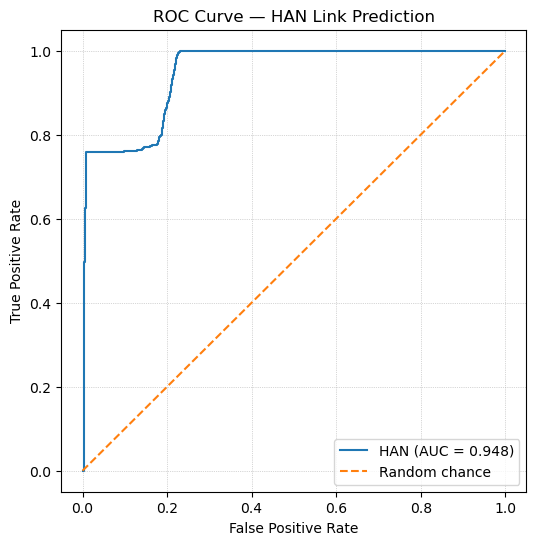

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1) Compute raw dot-product scores for all test positives & negatives
raw_pos = [(person_h[p] * attack_h[a]).sum().item() 
           for p, a in test_pos_edges]
raw_neg = [(person_h[p] * attack_h[a]).sum().item() 
           for p, a in test_neg_edges]

# 2) Build labels & scores
y_true  = [1]*len(raw_pos) + [0]*len(raw_neg)
y_score = raw_pos + raw_neg

# 3) Compute ROC and AUC
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_val     = roc_auc_score(y_true, y_score)
print(f"HAN Link Prediction AUC: {auc_val:.4f}")

# 4) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"HAN (AUC = {auc_val:.3f})")
plt.plot([0,1], [0,1], "--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — HAN Link Prediction")
plt.legend(loc="lower right")
plt.grid(linestyle=":", linewidth=0.5)
plt.show()

In [112]:
# HGT (Heterogeneous Graph Transformer)

In [114]:
import networkx as nx
from torch_geometric.utils import k_hop_subgraph

def extract_enclosing_subgraph(person_idx, attack_idx, k=2):
    # Use k_hop_subgraph to get nodes and edges within k hops of the two target nodes.
    target_nodes = [person_idx, len(persons_text) + attack_idx]  # using combined index where attack index is offset
    # Construct a homogeneous graph of Person+Attack for subgraph extraction
    # We'll use the same combined representation from R-GCN step:
    nodes, sub_edge_index, mapping, _ = k_hop_subgraph(target_nodes, num_hops=k, edge_index=edge_index_homo, relabel_nodes=True)
    # `nodes` are the original indices of subgraph nodes in combined indexing; `mapping` gives indices of the target nodes in the subgraph.
    # Build a networkx graph for distance calculation
    G = nx.Graph()
    # Add edges to networkx graph
    edge_array = sub_edge_index.numpy()
    for i in range(edge_array.shape[1]):
        u = edge_array[0, i]; v = edge_array[1, i]
        G.add_edge(int(u), int(v))
    # Compute shortest path lengths from each target in the subgraph
    src_map_idx = int(mapping[0])  # index of person target in subgraph
    dst_map_idx = int(mapping[1])  # index of attack target in subgraph
    dist_src = nx.single_source_shortest_path_length(G, src_map_idx)
    dist_dst = nx.single_source_shortest_path_length(G, dst_map_idx)
    # Assign DRNL labels to subgraph nodes
    labels = []
    for node in G.nodes():
        d1 = dist_src.get(node, 1e9)
        d2 = dist_dst.get(node, 1e9)
        if d1 == 0 or d2 == 0:
            labels.append(1)  # target nodes get label 1
        else:
            # DRNL labeling formula (Zhang & Chen 2018):
            dist_sum = d1 + d2
            dist_half = dist_sum // 2
            dist_mod = dist_sum % 2
            label = 1 + min(d1, d2)
            label += dist_half * (dist_half + dist_mod - 1)
            labels.append(int(label))
    labels = torch.tensor(labels, dtype=torch.long)
    # Gather node features for subgraph (original features plus label embedding later)
    sub_feat = all_features[nodes]  # use combined all_features from R-GCN step for original features
    return sub_edge_index, sub_feat, labels, src_map_idx, dst_map_idx

# Example: extract a subgraph for a training positive edge
p_idx, a_idx = train_pos_edges[0]
sub_edge_index, sub_feat, labels, src_idx, dst_idx = extract_enclosing_subgraph(p_idx, a_idx, k=2)
print(sub_edge_index.shape, sub_feat.shape, labels.shape, src_idx, dst_idx)
# sub_edge_index: [2, E_sub], sub_feat: [N_sub, F], labels: [N_sub], src_idx, dst_idx: positions of target nodes in subgraph

torch.Size([2, 18724]) torch.Size([683, 384]) torch.Size([683]) 203 675


In [115]:
from torch_geometric.nn import GCNConv

class SEALSubgraphGNN(nn.Module):
    def __init__(self, in_channels, label_emb_dim, hidden_channels):
        super().__init__()
        self.label_emb = nn.Embedding(100, label_emb_dim)  # assume label values <= 100
        self.conv1 = GCNConv(in_channels + label_emb_dim, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels*2, 1)  # will take the two target node embeddings for classification
    def forward(self, x, edge_index, labels, src_idx, dst_idx):
        # Embed structural labels and concatenate to features
        label_feat = self.label_emb(labels)           # [N_sub, label_emb_dim]
        x_input = torch.cat([x, label_feat], dim=1)   # [N_sub, in_channels + label_emb_dim]
        h = F.relu(self.conv1(x_input, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        # Get subgraph target node embeddings
        h_src = h[src_idx]; h_dst = h[dst_idx]
        # Concatenate and classify
        h_pair = torch.cat([h_src, h_dst], dim=-1)
        logit = self.lin(h_pair)  # output logit for link existence
        return torch.sigmoid(logit)

# Instantiate model
seal_model = SEALSubgraphGNN(in_channels=all_features.size(1), label_emb_dim=32, hidden_channels=64)
optimizer = torch.optim.Adam(seal_model.parameters(), lr=0.01)

In [116]:
# Prepare subgraph data for training set
train_subgraphs = []
for (p, a) in train_pos_edges:
    sub_edge_index, sub_feat, labels, src_idx, dst_idx = extract_enclosing_subgraph(p, a, k=2)
    train_subgraphs.append((sub_edge_index, sub_feat, labels, src_idx, dst_idx, 1))  # label=1 for positive
for (p, a) in train_neg_edges:
    sub_edge_index, sub_feat, labels, src_idx, dst_idx = extract_enclosing_subgraph(p, a, k=2)
    train_subgraphs.append((sub_edge_index, sub_feat, labels, src_idx, dst_idx, 0))  # label=0 for negative

# Training loop for SEAL
for epoch in range(1, 3):  # (using fewer epochs due to heavy subgraph extraction)
    random.shuffle(train_subgraphs)
    total_loss = 0
    for sub_edge_index, sub_feat, labels, src_idx, dst_idx, link_label in train_subgraphs:
        seal_model.train()
        optimizer.zero_grad()
        pred = seal_model(sub_feat, sub_edge_index, labels, src_idx, dst_idx)
        target = torch.tensor([link_label], dtype=torch.float)
        loss = F.binary_cross_entropy(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_subgraphs)
    print(f"Epoch {epoch}, SEAL training loss: {avg_loss:.4f}")

NodeNotFound: Source 682 is not in G

In [ ]:
# Evaluation for SEAL
seal_model.eval()
pos_probs = []
neg_probs = []
for (p, a) in test_pos_edges:
    sub_edge_index, sub_feat, labels, src_idx, dst_idx = extract_enclosing_subgraph(p, a, k=2)
    prob = seal_model(sub_feat, sub_edge_index, labels, src_idx, dst_idx).item()
    pos_probs.append(prob)
for (p, a) in test_neg_edges:
    sub_edge_index, sub_feat, labels, src_idx, dst_idx = extract_enclosing_subgraph(p, a, k=2)
    prob = seal_model(sub_feat, sub_edge_index, labels, src_idx, dst_idx).item()
    neg_probs.append(prob)
auc = roc_auc_score([1]*len(pos_probs)+[0]*len(neg_probs), pos_probs+neg_probs)
print(f"SEAL Link Prediction AUC: {auc:.4f}")
# Hits@K
K = 10
hits = 0
for p, a in test_pos_edges:
    # generate candidates for this attack
    candidates = random.sample(all_person_idx, 50) + [p]  # 50 random negatives + true
    scores = []
    for c in candidates:
        sub_edge_index, sub_feat, labels, src_idx, dst_idx = extract_enclosing_subgraph(c, a, k=2)
        prob = seal_model(sub_feat, sub_edge_index, labels, src_idx, dst_idx).item()
        scores.append(prob)
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:K]
    if len(candidates)-1 in top_idx:
        hits += 1
print(f"SEAL Hits@{K}: {hits/len(test_pos_edges):.4f}")

In [117]:
# =============================================================================
#  SEAL  LINK‑PREDICTION  PIPELINE  (robust k‑hop extraction + tqdm)
#  ---------------------------------------------------------------------------
#  • assumes you already built:
#       - edge_index_homo  (shape [2,E] over combined Person+Attack graph)
#       - all_features     (tensor [N_total, F])  for node attributes
#       - train_pos_edges , train_neg_edges , test_pos_edges , test_neg_edges
#       - N_person (number of Person nodes)   ,  existing_pairs  (set of edges)
#  • trains a simple 2‑layer GCN on each k‑hop enclosing subgraph (SEAL)
#  • k increases up to k_max if endpoints are >k hops apart
# =============================================================================
import torch, random, math, tqdm, numpy as np, networkx as nx
import torch.nn.functional as F
from torch_geometric.utils import k_hop_subgraph
from torch_geometric.nn import GCNConv

# ------------------------------------------------------------------
# 1.  Helper: DRNL node labelling
# ------------------------------------------------------------------
def drnl_label(dist_src, dist_dst):
    dist_sum = dist_src + dist_dst
    return 1 + min(dist_src, dist_dst) + dist_sum * (dist_sum + 1) // 2

# ------------------------------------------------------------------
# 2.  k‑hop enclosing subgraph extractor (with safe fallback)
# ------------------------------------------------------------------
def extract_enclosing_subgraph(p_idx, a_idx, k=2):
    """Return (edge_index, feat, labels, src_pos, dst_pos) or None if disconnected."""
    target_nodes = [p_idx, N_person + a_idx]       # combined indexing
    nodes, sub_ei, mapping, _ = k_hop_subgraph(
        target_nodes, num_hops=k, edge_index=edge_index_homo,
        relabel_nodes=True
    )
    if len(mapping) < 2:                           # one endpoint missing
        return None
    src_map, dst_map = map(int, mapping[:2])

    # build NetworkX graph for distance
    G = nx.Graph()
    G.add_nodes_from(range(nodes.numel()))
    G.add_edges_from(sub_ei.t().tolist())

    # shortest‑path distances (within cutoff k)
    dist_src = nx.single_source_shortest_path_length(G, src_map, cutoff=k)
    dist_dst = nx.single_source_shortest_path_length(G, dst_map, cutoff=k)

    labels = []
    for n in G.nodes():
        d1 = dist_src.get(n, 1e8)
        d2 = dist_dst.get(n, 1e8)
        label = 0 if (n == src_map or n == dst_map) else drnl_label(d1, d2)
        labels.append(label)
    labels = torch.tensor(labels, dtype=torch.long)

    sub_feat = all_features[nodes]                 # features for subgraph nodes
    return sub_ei, sub_feat, labels, src_map, dst_map

def safe_subgraph(p_idx, a_idx, k_max=3):
    for k in range(1, k_max+1):
        sub = extract_enclosing_subgraph(p_idx, a_idx, k=k)
        if sub is not None:
            return sub
    return None                                    # still disconnected

# ------------------------------------------------------------------
# 3.  Build training subgraphs with tqdm progress bar
# ------------------------------------------------------------------
train_subgraphs = []
for p,a in tqdm.tqdm(train_pos_edges, desc="Pos subgraphs"):
    sub = safe_subgraph(p, a, k_max=3)
    if sub:  train_subgraphs.append((*sub, 1))
for p,a in tqdm.tqdm(train_neg_edges, desc="Neg subgraphs"):
    sub = safe_subgraph(p, a, k_max=3)
    if sub:  train_subgraphs.append((*sub, 0))

print(f"Prepared {len(train_subgraphs)} training subgraphs")

# ------------------------------------------------------------------
# 4.  Simple SEAL model
# ------------------------------------------------------------------
class SEALGCN(torch.nn.Module):
    def __init__(self, in_ch, label_dim=32, hidden=64):
        super().__init__()
        self.label_emb = torch.nn.Embedding(1000, label_dim)   # DRNL labels rarely exceed 1k
        self.conv1 = GCNConv(in_ch + label_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden*2, 1)              # cat(src,dst)
    def forward(self, x, edge_index, labels, src_idx, dst_idx):
        x = torch.cat([x, self.label_emb(labels)], 1)
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        h_pair = torch.cat([h[src_idx], h[dst_idx]], 0)
        return torch.sigmoid(self.lin(h_pair))

model = SEALGCN(in_ch=all_features.size(1))
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------------
# 5.  Train SEAL with tqdm
# ------------------------------------------------------------------
EPOCHS = 3
for epoch in range(1, EPOCHS+1):
    random.shuffle(train_subgraphs)
    total = 0; running_loss = 0.0
    for sub_ei, sub_x, lab, sidx, didx, y in tqdm.tqdm(train_subgraphs,
                                                       desc=f"Epoch {epoch}"):
        model.train(); opt.zero_grad()
        pred = model(sub_x, sub_ei, lab, sidx, didx)
        loss = F.binary_cross_entropy(pred, torch.tensor([y], dtype=torch.float))
        loss.backward(); opt.step()
        running_loss += loss.item(); total += 1
    print(f"Epoch {epoch}: avg loss {running_loss/total:.4f}")

# ------------------------------------------------------------------
# 6.  Evaluation on test set (precision / recall / accuracy @ K)
# ------------------------------------------------------------------
model.eval()
K = 10
total_true_returned = accuracy_hits = 0
attack2positives = {}
for p,a in test_pos_edges:
    attack2positives.setdefault(a, []).append(p)

for a,true_ps in tqdm.tqdm(attack2positives.items(), desc="Eval attacks"):
    true_ps = true_ps[1] if isinstance(true_ps, tuple) else true_ps
    neg = random.sample(all_person_idx, 100)
    neg = [x for x in neg if (x,a) not in existing_pairs]
    candidates = list(set(true_ps + neg))

    # score each candidate via subgraph
    scores=[]
    for pid in candidates:
        sub = safe_subgraph(pid, a, k_max=3)
        if not sub:                      # skip if disconnected
            scores.append((-1e9, pid))
            continue
        sub_ei, sub_x, lab, sidx, didx = sub
        score = model(sub_x, sub_ei, lab, sidx, didx).item()
        scores.append((score, pid))

    top_ids = {pid for score,pid in sorted(scores, reverse=True)[:K]}
    hits_here = len(set(true_ps).intersection(top_ids))
    total_true_returned += hits_here
    if hits_here > 0:
        accuracy_hits += 1

num_queries = len(attack2positives)
precision_at_k = total_true_returned / (num_queries * K)
recall_at_k    = total_true_returned / sum(len(v) for v in attack2positives.values())
accuracy_at_k  = accuracy_hits       / num_queries

print(f"\nSEAL  Precision@{K}: {precision_at_k:.3f}")
print(f"SEAL  Recall@{K}:    {recall_at_k:.3f}")
print(f"SEAL  Accuracy@{K}:  {accuracy_at_k:.3f}")

Neg subgraphs: 100%|██████████████████████████████████████████████████████| 9701/9701 [00:13<00:00, 729.49it/s]


Prepared 19402 training subgraphs


Epoch 1:   0%|                                                                       | 0/19402 [00:00<?, ?it/s]


IndexError: index out of range in self

In [136]:
p= 0.202
r = 0.434
f = 2*(p*r)/(p+r)
f

0.275685534591195

In [1]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install matplotlib

In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install matplotlib



ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/Users/chengxiyao/miniconda3/lib/python3.10/site-packages/matplotlib-3.7.1.dist-info/METADATA'



In [8]:
!/Users/chengxiyao/miniconda3/bin/python -m pip uninstall -y matplotlib
!/Users/chengxiyao/miniconda3/bin/python -m pip cache purge

Files removed: 1874 (1741.7 MB)


In [10]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 63.4 MB/s  0:00:00


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random, itertools, math, tqdm
from neo4j import GraphDatabase
from sentence_transformers import SentenceTransformer
from torch_geometric.data import HeteroData
from torch_geometric.nn import RGCNConv, SAGEConv, HeteroConv, HANConv
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ----------------------
# 1. CONNECT & PULL FROM NEO4J
# ----------------------
NEO4J_URI      = "bolt://localhost:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "root1234"
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

cypher_person = """
MATCH (p:Person)
OPTIONAL MATCH (p)-[:HAS_EXPERIENCE]->(e:Experience)
OPTIONAL MATCH (p)-[:HAS_SKILL]->(s:Skill)
WITH id(p) AS pid,
     p.name AS pname,
     collect(e.role + ' ; ' + coalesce(e.description,'')) AS exps,
     collect(s.name) AS skills
RETURN pid,
       pname + ' ; ' + apoc.text.join(exps,' ; ') + ' ; ' + apoc.text.join(skills,' ; ') AS blob
"""
cypher_attack = """
MATCH (a:Attack)
RETURN id(a) AS aid,
       coalesce(a.name,'') + ' ; ' + coalesce(a.description,'') AS blob
"""
cypher_edges = """
MATCH (p:Person)-[:CAN_MITIGATE]->(a:Attack)
RETURN id(p) AS pid, id(a) AS aid
"""

person_id_map, attack_id_map = {}, {}
persons_text, attacks_text = [], []
person_attack_edges = []

with driver.session() as sess:
    for rec in sess.run(cypher_person):
        pid, blob = rec["pid"], (rec["blob"] or "").strip()
        if not blob: blob = rec["pname"]
        person_id_map[pid] = len(person_id_map)
        persons_text.append(blob)
    for rec in sess.run(cypher_attack):
        aid, blob = rec["aid"], (rec["blob"] or "").strip()
        attack_id_map[aid] = len(attack_id_map)
        attacks_text.append(blob)
    for rec in sess.run(cypher_edges):
        p_idx = person_id_map.get(rec["pid"])
        a_idx = attack_id_map.get(rec["aid"])
        if p_idx is not None and a_idx is not None:
            person_attack_edges.append((p_idx, a_idx))

# ----------------------
# 2. EMBED WITH BERT
# ----------------------
bert = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
BATCH = 128

def batch_embed(texts):
    embeds = []
    for batch in tqdm.tqdm(
        list(itertools.zip_longest(*[iter(texts)]*BATCH, fillvalue=None)),
        total=math.ceil(len(texts)/BATCH), desc="Embedding"
    ):
        chunk = [t for t in batch if t is not None]
        embeds.extend(bert.encode(chunk, show_progress_bar=False, convert_to_tensor=True))
    return torch.stack(embeds)

person_features = batch_embed(persons_text)   # [N_person, 384]
attack_features = batch_embed(attacks_text)   # [N_attack, 384]

# ----------------------
# 3. BUILD HETERODATA & SPLITS
# ----------------------
data = HeteroData()
data["Person"].x = person_features
data["Attack"].x = attack_features
data["Person"].num_nodes = person_features.size(0)
data["Attack"].num_nodes = attack_features.size(0)

edge_index_P2A = torch.tensor(list(zip(*person_attack_edges)), dtype=torch.long)
data[("Person","mitigates","Attack")].edge_index = edge_index_P2A
edge_index_A2P = torch.stack([edge_index_P2A[1], edge_index_P2A[0]], dim=0)
data[("Attack","rev_mitigates","Person")].edge_index = edge_index_A2P

# train/test split
random.seed(42)
all_edges = person_attack_edges.copy()
random.shuffle(all_edges)
split = int(0.8 * len(all_edges))
train_pos_edges = all_edges[:split]
test_pos_edges  = all_edges[split:]

all_person_idx = list(range(len(persons_text)))
all_attack_idx = list(range(len(attacks_text)))
existing_pairs = set(person_attack_edges)

def sample_neg(n):
    neg = []
    while len(neg) < n:
        p = random.choice(all_person_idx)
        a = random.choice(all_attack_idx)
        if (p,a) not in existing_pairs:
            neg.append((p,a))
            existing_pairs.add((p,a))
    return neg

train_neg_edges = sample_neg(len(train_pos_edges))
test_neg_edges  = sample_neg(len(test_pos_edges))

# ----------------------
# 4. PREPARE GRAPH STRUCTURES
# ----------------------
Np, Na = person_features.size(0), attack_features.size(0)

# for GCN/SAGE/HAN: homograph
src_p2a = edge_index_P2A[0].tolist()
dst_p2a = [d+Np for d in edge_index_P2A[1].tolist()]
src_a2p = [s+Np for s in edge_index_A2P[0].tolist()]
dst_a2p = edge_index_A2P[1].tolist()
edge_index_homo = torch.tensor([src_p2a+src_a2p, dst_p2a+dst_a2p], dtype=torch.long)

# for R-GCN: typed graph
edge_index_rgcn = torch.tensor([src_p2a, dst_p2a], dtype=torch.long)
edge_index_rgcn = torch.cat([edge_index_rgcn,
    torch.tensor([src_a2p, dst_a2p],dtype=torch.long)], dim=1)
edge_type_rgcn  = torch.tensor([0]*len(src_p2a) + [1]*len(src_a2p), dtype=torch.long)

# HAN uses the same hetero data dicts
x_dict = {"Person": data["Person"].x, "Attack": data["Attack"].x}
edge_dict = data.edge_index_dict

# ----------------------
# 5. MODEL CLASSES
# ----------------------
class RGCNModel(nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super().__init__()
        self.conv1 = RGCNConv(in_ch, hid_ch, 2)
        self.conv2 = RGCNConv(hid_ch, out_ch, 2)
    def forward(self, x, ei, et):
        h = F.relu(self.conv1(x, ei, et))
        return self.conv2(h, ei, et)

class SAGEModel(nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch, meta):
        super().__init__()
        self.conv1 = HeteroConv({
            ("Person","mitigates","Attack"): SAGEConv((-1,-1),hid_ch),
            ("Attack","rev_mitigates","Person"): SAGEConv((-1,-1),hid_ch)
        }, aggr="sum")
        self.conv2 = HeteroConv({
            ("Person","mitigates","Attack"): SAGEConv((-1,-1),out_ch),
            ("Attack","rev_mitigates","Person"): SAGEConv((-1,-1),out_ch)
        }, aggr="sum")
        self.meta = meta
    def forward(self, x_dict, edge_index_dict):
        h1 = self.conv1(x_dict, edge_index_dict)
        h1 = {k: F.relu(v) for k,v in h1.items()}
        return self.conv2(h1, edge_index_dict)

class HANModel(nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch, meta):
        super().__init__()
        self.han1 = HANConv(in_ch, hid_ch, heads=8, dropout=0.6, metadata=meta)
        self.han2 = HANConv(hid_ch, out_ch, heads=1, dropout=0.6, metadata=meta)
    def forward(self, x_dict, edge_index_dict):
        h = self.han1(x_dict, edge_index_dict)
        h = {k: F.relu(v) for k,v in h.items()}
        return self.han2(h, edge_index_dict)

# ----------------------
# 6. INSTANTIATE & TRAIN
# ----------------------
# R-GCN
model_rgcn = RGCNModel(person_features.size(1), 64, 32)
opt_rgcn   = torch.optim.Adam(model_rgcn.parameters(), lr=0.01)
for epoch in range(5):
    model_rgcn.train()
    emb_rgcn = model_rgcn(torch.cat([person_features, attack_features],dim=0),
                          edge_index_rgcn, edge_type_rgcn)
    pos = torch.stack([(emb_rgcn[p]*emb_rgcn[Np+a]).sum() for p,a in train_pos_edges])
    neg = torch.stack([(emb_rgcn[p]*emb_rgcn[Np+a]).sum() for p,a in train_neg_edges])
    loss = F.binary_cross_entropy_with_logits(pos,torch.ones_like(pos)) + \
           F.binary_cross_entropy_with_logits(neg,torch.zeros_like(neg))
    opt_rgcn.zero_grad(); loss.backward(); opt_rgcn.step()

# SAGE
model_sage = SAGEModel(person_features.size(1), 64, 32, data.metadata())
opt_sage   = torch.optim.Adam(model_sage.parameters(), lr=0.01)
for epoch in range(5):
    model_sage.train()
    out = model_sage(x_dict, edge_dict)
    ph, ah = out["Person"], out["Attack"]
    pos = torch.stack([(ph[p]*ah[a]).sum() for p,a in train_pos_edges])
    neg = torch.stack([(ph[p]*ah[a]).sum() for p,a in train_neg_edges])
    loss = F.binary_cross_entropy_with_logits(pos,torch.ones_like(pos)) + \
           F.binary_cross_entropy_with_logits(neg,torch.zeros_like(neg))
    opt_sage.zero_grad(); loss.backward(); opt_sage.step()

# HAN
model_han = HANModel(person_features.size(1), 64, 32, data.metadata())
opt_han   = torch.optim.Adam(model_han.parameters(), lr=0.005)
for epoch in range(5):
    model_han.train()
    out = model_han(x_dict, edge_dict)
    ph, ah = out["Person"], out["Attack"]
    pos = torch.stack([(ph[p]*ah[a]).sum() for p,a in train_pos_edges])
    neg = torch.stack([(ph[p]*ah[a]).sum() for p,a in train_neg_edges])
    loss = F.binary_cross_entropy_with_logits(pos,torch.ones_like(pos)) + \
           F.binary_cross_entropy_with_logits(neg,torch.zeros_like(neg))
    opt_han.zero_grad(); loss.backward(); opt_han.step()

# ----------------------
# 7. EVALUATE & PLOT ROCs
# ----------------------
def get_scores(model_emb):
    pos = [(model_emb[p]*model_emb[Np+a]).sum().item() for p,a in test_pos_edges]
    neg = [(model_emb[p]*model_emb[Np+a]).sum().item() for p,a in test_neg_edges]
    y, s = [1]*len(pos)+[0]*len(neg), pos+neg
    fpr, tpr, _ = roc_curve(y, s)
    return fpr, tpr, auc(fpr,tpr)

# embeddings
emb_rgcn = model_rgcn(torch.cat([person_features, attack_features],dim=0),
                      edge_index_rgcn, edge_type_rgcn).detach()
out_sage = model_sage(x_dict, edge_dict)
emb_sage = torch.cat([out_sage["Person"], out_sage["Attack"]], dim=0).detach()
out_han  = model_han(x_dict, edge_dict)
emb_han  = torch.cat([out_han["Person"], out_han["Attack"]],    dim=0).detach()

fpr_r, tpr_r, auc_r = get_scores(emb_rgcn)
fpr_s, tpr_s, auc_s = get_scores(emb_sage)
fpr_h, tpr_h, auc_h = get_scores(emb_han)

plt.figure(figsize=(8,6))
plt.plot(fpr_r, tpr_r, label=f"R-GCN (AUC={auc_r:.3f})")
plt.plot(fpr_s, tpr_s, label=f"GraphSAGE (AUC={auc_s:.3f})")
plt.plot(fpr_h, tpr_h, label=f"HAN      (AUC={auc_h:.3f})")
plt.plot([0,1],[0,1],"--",label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves: R-GCN vs GraphSAGE vs HAN"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: } {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: CAN_MITIGATE)} {position: line: 2, column: 20, offset: 20} for query: '\nMATCH (p:Person)-[:CAN_MITIGATE]->(a:Attack)\nRETURN id(p) AS pid, id(a) AS aid\n'
Embedding: 100%|████████████████████████████████| 13/13 [00:11<00:00,  1.13it/s]


IndexError: index 1 is out of bounds for dimension 0 with size 0